In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
from dataclasses import dataclass

from tqdm import tqdm

import orjson
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm, trange

from sae_java_bug.logger import logger
from sae_java_bug.sparse_autoencoders.utils import get_device


@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


In [17]:
import glob
import orjson
import torch
from tqdm import tqdm
from sae_java_bug.sparse_autoencoders.sae_exploration import ActivationsSchema

from sae_java_bug.logger import logger
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from typing import Dict, Tuple
from sklearn.model_selection import KFold

class MLP(nn.Module):
    def __init__(
        self, input_dim, output_dim=2, hidden=(128, 64), dropout=0.3, use_bn=True
    ):
        super().__init__()
        h1, h2 = hidden
        self.use_bn = use_bn

        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1) if use_bn else nn.Identity()
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2) if use_bn else nn.Identity()
        self.fc3 = nn.Linear(h2, output_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc3(x)  # logits
        return x

def evaluate(loader, model, device=get_device(verbose=False)):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
    y_true = torch.cat(all_labels)
    y_pred = torch.cat(all_preds)
    return accuracy_score(y_true, y_pred), y_true, y_pred

def train_small_mlp_kfold(class_negative: torch.Tensor, class_positive: torch.Tensor, k=5):

    # Create labels
    vuln_labels = torch.ones(class_positive.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(class_negative.size(0), dtype=torch.float32)

    all_features = torch.cat((class_positive, class_negative), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # print("All Features Shape:", all_features.shape)
    # print("All Labels Shape:", all_labels.shape)

    dataset = TensorDataset(all_features, all_labels)

    # Initialize KFold
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold = 1
    fold_acc = []

    for train_idx, test_idx in kf.split(all_features):

        # print(f"\n===== Fold {fold}/{k} =====")
        fold += 1

        train_subset = torch.utils.data.Subset(dataset, train_idx)
        test_subset  = torch.utils.data.Subset(dataset, test_idx)

        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, drop_last=True)
        test_loader  = DataLoader(test_subset, batch_size=1000, shuffle=False, drop_last=False)

        # new model per fold
        model = MLP(input_dim=all_features.size(1)).to(device)
        # activate gradients
        model.train()
        torch.set_grad_enabled(True)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        num_epochs = 50  # often fewer needed

        for epoch in range(num_epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                optimizer.zero_grad()
                logits = model(x_batch)
                loss = F.cross_entropy(logits, y_batch)
                loss.backward()
                optimizer.step()

        # evaluate this fold
        acc, _, _ = evaluate(test_loader, model, device)
        fold_acc.append(acc)

    #     print(f"Fold Test Accuracy: {acc:.4f}")

    # print("\n===== K-Fold Results =====")
    # print(f"Fold Accuracies: {fold_acc}")
    # print(f"Mean Accuracy: {sum(fold_acc)/len(fold_acc):.4f}")

    return sum(fold_acc)/len(fold_acc)


device = get_device(verbose=True)

layer_scores = {}
RUN_ID = "run_20260127_044329"
RUN_ID = "run_20260127_195450" # this is the swapped operands activations
RUN_ID = "run_20260127_202722" # this is the cwes data
RUN_ID = "run_20260128_184854" # Trained with DeltaSeccommits


files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"), key=lambda x: int(x.split("layer_")[1].split("_")[0]))

@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


def compute_lda_fisher_scores(secure_features: torch.Tensor, vulnerable_features: torch.Tensor) -> float:
    # Create labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA — build dataset for layer
    X = all_features.numpy()
    y = all_labels.numpy()

    # Train LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(X, y)

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    mean_diff = vuln_proj.mean() - safe_proj.mean()
    var_sum = vuln_proj.var() + safe_proj.var()
    fisher_score = (mean_diff ** 2) / (var_sum + 1e-8)

    return float(fisher_score)


2026-01-28 20:46:11 [info     ] Getting device.                device=mps


In [18]:


FisherScoreMap: Dict[Tuple[str, str], float] = {}
ProbingDataMap: Dict[Tuple[str, str], float] = {}
from typing import List
from collections import defaultdict

all_vulnerable_features: Dict[str, List[float]] = defaultdict(list)
all_safe_features : Dict[str, List[float]] = defaultdict(list)

for activation_file in files:
    logger.info("Processing file.", file=activation_file)

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    
    # Loads activations.
    with open(activation_file, "r") as f: 
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            
            cwe = data["cwe"]
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)


            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)
            

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )

        print("Vulnerable Features Shape:", vulnerable_features.shape , "Safe Features Shape:", safe_features.shape)
        print("CWE:", cwe, "Vulnerable Shape:", vulnerable_features.shape, "Safe Shape:", safe_features.shape)
    
        all_vulnerable_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ] = torch.tensor(vulnerable_features)
        all_safe_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ]= torch.tensor(safe_features)
        

    # Save for later reuse
    layer_id = activation_file.split("layer_")[1].split("_")[0]
    torch.save(vulnerable_features, f"../artifacts/activations/{RUN_ID}/vulnerable_layer_{layer_id}.pt")
    torch.save(safe_features, f"../artifacts/activations/{RUN_ID}/safe_layer_{layer_id}.pt")

2026-01-28 20:46:11 [info     ] Processing file.               file=../artifacts/activations/run_20260128_184854/activations_layer_0_sae_blocks.0.hook_resid_post_component_hook_resid_post.hook_sae_acts_post.jsonl


Loading:  20%|█▉        | 490/2500 [00:09<01:10, 28.41 lines/s] 

2026-01-28 20:46:21 [error    ] JSON decoding error: unexpected end of data: line 1 column 79820 (char 79819)


Loading:  20%|█▉        | 491/2500 [00:09<00:40, 49.59 lines/s]
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_6340/3811333901.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ] = torch.tensor(vulnerable_features)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_6340/3811333901.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ]= torch.tensor(safe_features)


Vulnerable Features Shape: torch.Size([491, 16384]) Safe Features Shape: torch.Size([491, 16384])
CWE: CWE-89 Vulnerable Shape: torch.Size([491, 16384]) Safe Shape: torch.Size([491, 16384])


In [19]:
for key, data in tqdm(cwe_tensor_map.items()):
    try:
        # Compute LDA Fisher Score for this layer and CWE
        fisher_score = compute_lda_fisher_scores(data.secure, data.vulnerable)
        # logger.info(f"  LDA Fisher Score for CWE {key}: {fisher_score:.4f}")
        FisherScoreMap[(layer_id, key)] = fisher_score
        probe_score = train_small_mlp_kfold(data.secure, data.vulnerable, k=5)
        ProbingDataMap[(layer_id, key)] = probe_score
    except Exception as e:
        logger.error(f"Error processing CWE {key} in layer {layer_id}: {e}")


fisher_score = compute_lda_fisher_scores(safe_features, vulnerable_features)
FisherScoreMap[(layer_id, "ALL")] = fisher_score

 91%|█████████ | 20/22 [00:26<00:01,  1.63it/s]

2026-01-28 20:46:48 [error    ] Error processing CWE CWE-415 in layer 0: The number of samples must be more than the number of classes.


100%|██████████| 22/22 [00:27<00:00,  1.23s/it]


2026-01-28 20:46:50 [info     ] Layer 0, CWE CWE-200: LDA Fisher Score = 2.8499, Probing Accuracy = 0.4286


Loading:  19%|█▊        | 464/2500 [00:00<00:02, 923.99 lines/s]

2026-01-28 20:46:51 [error    ] JSON decoding error: unexpected end of data: line 1 column 79820 (char 79819)


Loading:  20%|█▉        | 491/2500 [00:00<00:02, 909.65 lines/s]


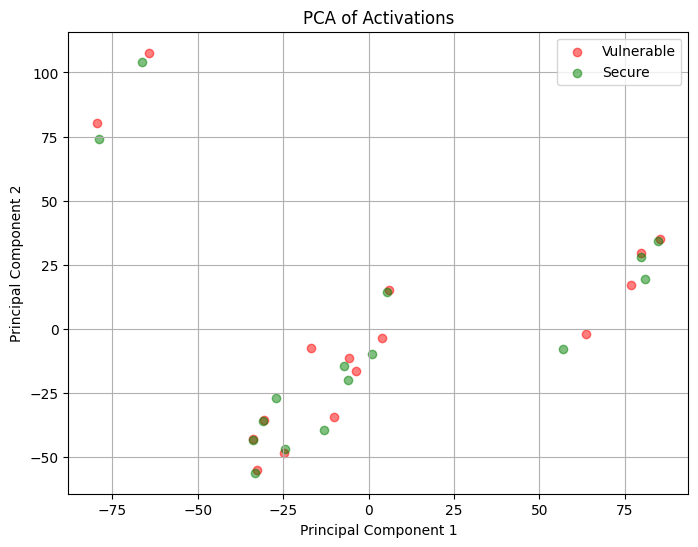

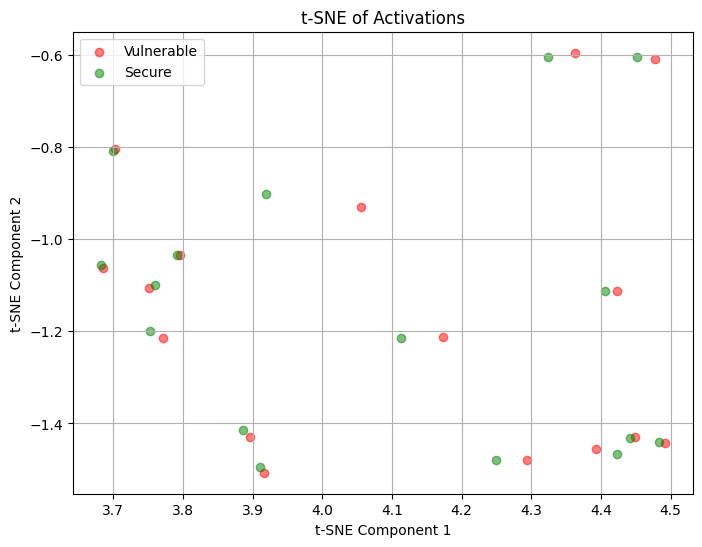

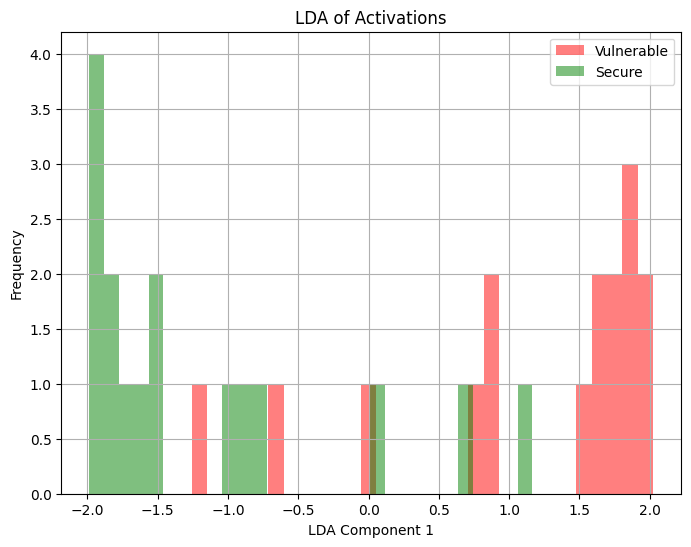

2026-01-28 20:46:51 [info     ] Layer 0, CWE CWE-400: LDA Fisher Score = 13.2884, Probing Accuracy = 0.1444


Loading:  19%|█▊        | 468/2500 [00:00<00:02, 760.85 lines/s]

2026-01-28 20:46:52 [error    ] JSON decoding error: unexpected end of data: line 1 column 79820 (char 79819)


Loading:  20%|█▉        | 491/2500 [00:00<00:02, 756.58 lines/s]


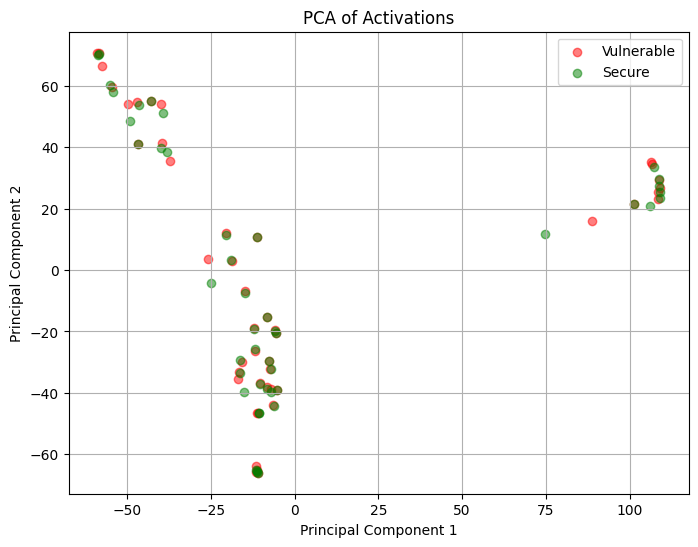

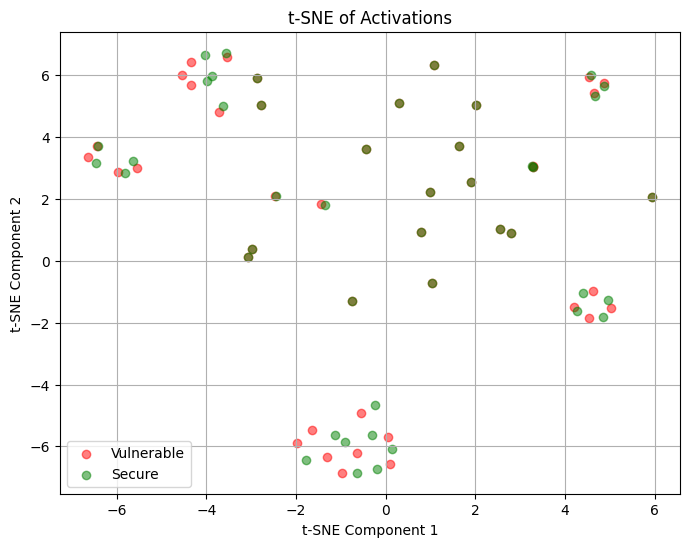

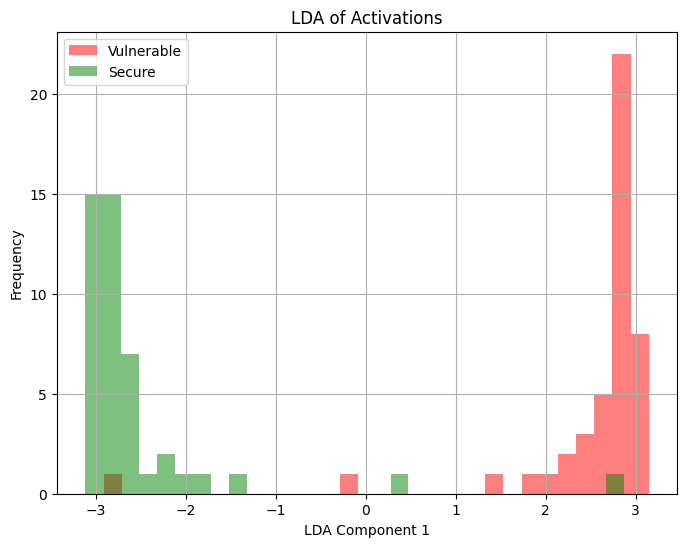

2026-01-28 20:46:53 [info     ] Layer 0, CWE CWE-125: LDA Fisher Score = 8.1533, Probing Accuracy = 0.3714


Loading:  16%|█▋        | 407/2500 [00:00<00:02, 827.53 lines/s]

2026-01-28 20:46:54 [error    ] JSON decoding error: unexpected end of data: line 1 column 79820 (char 79819)


Loading:  20%|█▉        | 491/2500 [00:00<00:02, 806.87 lines/s]


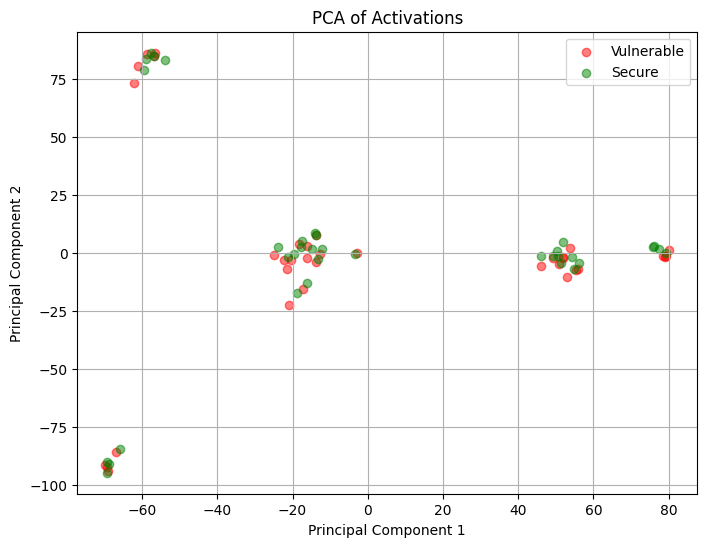

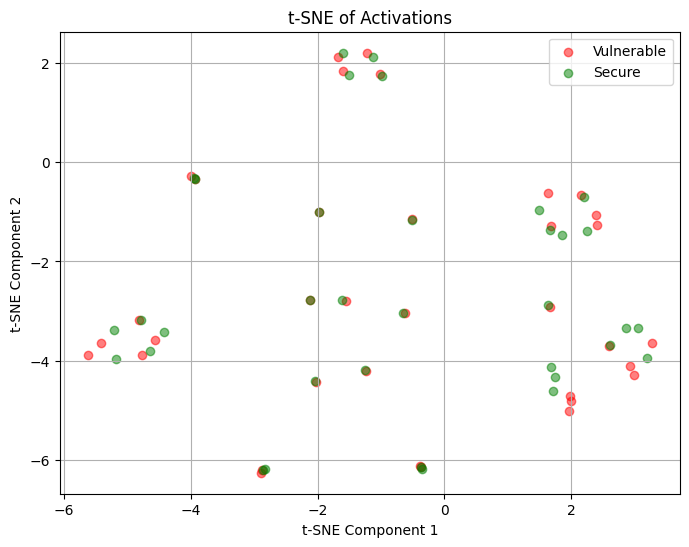

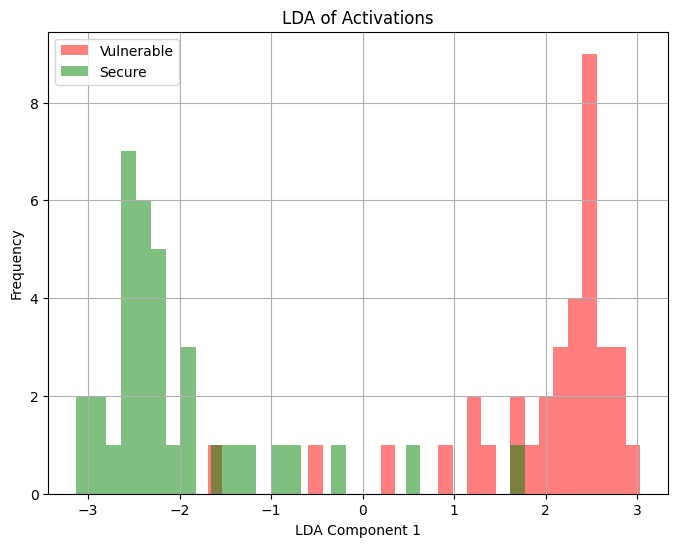

2026-01-28 20:46:55 [info     ] Layer 0, CWE CWE-416: LDA Fisher Score = 4.6557, Probing Accuracy = 0.5000


Loading:  16%|█▌        | 400/2500 [00:00<00:02, 978.76 lines/s] 

2026-01-28 20:46:55 [error    ] JSON decoding error: unexpected end of data: line 1 column 79820 (char 79819)


Loading:  20%|█▉        | 491/2500 [00:00<00:02, 985.80 lines/s]


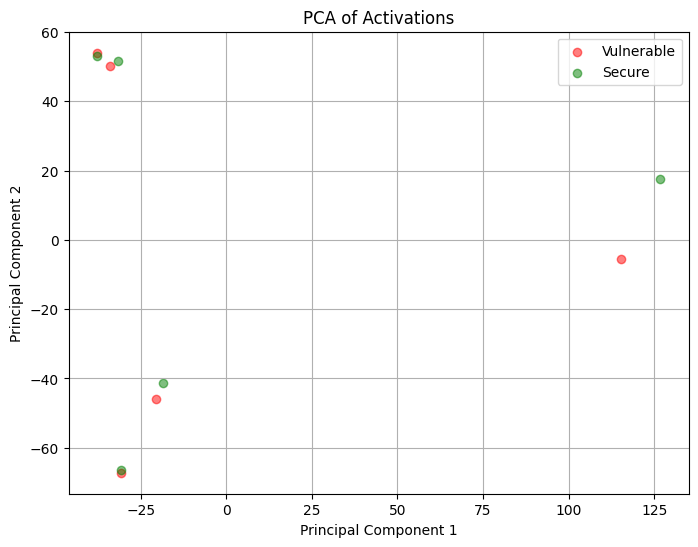

ValueError: perplexity (30.0) must be less than n_samples (10)

In [20]:
files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"))

def get_data(files: list, layer_id: int, cwe: str):
    # Read file and extract data for given layer_id and cwe
    for file in files:
        if f"layer_{layer_id}_" in file:
            activation_file = file
            break
    else:
        raise ValueError(f"Layer {layer_id} not found in files.")
    

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    # Loads activations.
    with open(activation_file, "r") as f:
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            _cwe = data["cwe"]
            if _cwe != cwe:
                continue
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            # print(f"Vuln ID: {activations.vuln_id}, Layer: {activations.layer}")
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)



            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )


    return cwe_tensor_map[cwe]


def plot_pca(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # PCA
    pca = PCA(n_components=2)
    proj = pca.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("PCA of Activations")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid()
    plt.show()


def plot_lda(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(all_features.numpy(), all_labels.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.hist(vuln_proj, bins=30, alpha=0.5, label=label_vulnerable, color="r")
    plt.hist(safe_proj, bins=30, alpha=0.5, label=label_secure, color="g")
    plt.title("LDA of Activations")
    plt.xlabel("LDA Component 1")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()


def plot_tsne(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    proj = tsne.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("t-SNE of Activations")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend()
    plt.grid()
    plt.show()

for key in FisherScoreMap:
    if key == "ALL":
        continue
    logger.info(f"Layer {key[0]}, CWE {key[1]}: LDA Fisher Score = {FisherScoreMap[key]:.4f}, Probing Accuracy = {ProbingDataMap[key]:.4f}")
    layer_id = int(key[0])
    cwe = key[1]
    data = get_data(files, layer_id, cwe)
    plot_pca(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")
    plot_tsne(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")
    plot_lda(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")

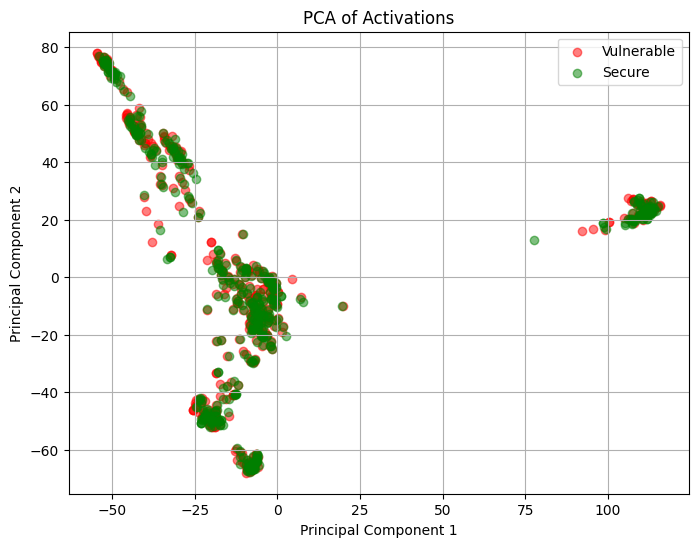

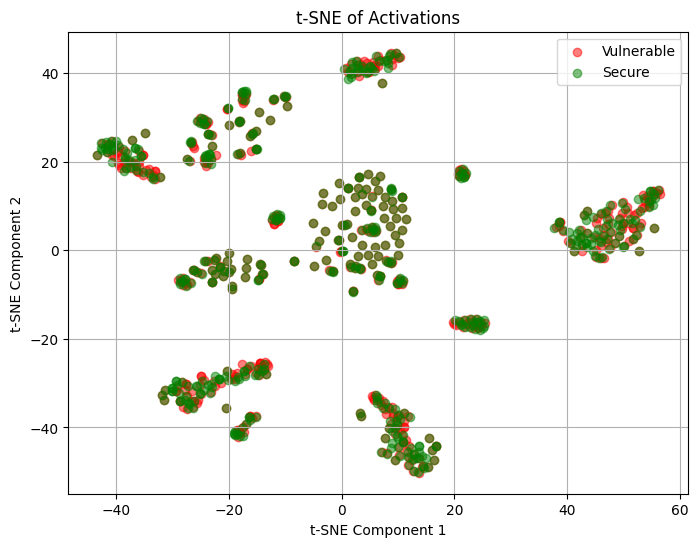

In [24]:
plot_pca(all_safe_features["layer_0"], all_vulnerable_features["layer_0"], label_secure="Secure", label_vulnerable="Vulnerable")

plot_tsne(all_safe_features["layer_0"], all_vulnerable_features["layer_0"], label_secure="Secure", label_vulnerable="Vulnerable")


## Dump

In [25]:
# import numpy as np
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# def plot_pca_subplots(cwe_data_map: Dict[str, VulnerabilityData]):
#     """Create subplots for each CWE"""
#     n_cwes = len(cwe_data_map)
#     n_cols = 3
#     n_rows = (n_cwes + n_cols - 1) // n_cols
    
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
#     axes = axes.flatten() if n_cwes > 1 else [axes]
    
#     for idx, (cwe, data) in enumerate(cwe_data_map.items()):
#         pca = PCA(n_components=2)
        
#         # Fit PCA on combined data
#         combined_data = torch.cat([data.vulnerable, data.secure], dim=0).numpy()
#         pca_transformed = pca.fit_transform(combined_data)
        
#         # Split back into vulnerable and safe
#         vuln_size = data.vulnerable.shape[0]
#         vuln_pca = pca_transformed[:vuln_size]
#         safe_pca = pca_transformed[vuln_size:]
        
#         ax = axes[idx]
#         ax.scatter(
#             vuln_pca[:, 0],
#             vuln_pca[:, 1],
#             c="red",
#             label="Vulnerable",
#             alpha=0.7,
#         )
#         ax.scatter(
#             safe_pca[:, 0],
#             safe_pca[:, 1],
#             c="blue",
#             label="Safe",
#             alpha=0.7,
#         )
#         ax.set_xlabel("PCA Component 1")
#         ax.set_ylabel("PCA Component 2")
#         ax.set_title(f"{cwe}")
#         ax.legend()
    
#     # Hide unused subplots
#     for idx in range(n_cwes, len(axes)):
#         axes[idx].axis('off')
    
#     plt.suptitle("PCA of Sparse Autoencoder Activations by CWE", fontsize=16, y=1.00)
#     plt.tight_layout()
#     plt.show()


# # Plot subplots for each CWE
# print("Plotting PCA subplots for each CWE")
# plot_pca_subplots(cwe_tensor_map)


Claude


Loading secure activations...
Secure shape: torch.Size([491, 16384])
Vulnerable shape: torch.Size([491, 16384])

  Secure Code Activation Distribution Statistics
Dataset Size:
  Samples: 491
  Features: 16,384

Basic Statistics:
  Mean:     0.513059
  Std:      1.244689
  Median:   0.000000
  Min:      0.000000
  Max:     90.626701

Distribution Shape:
  Skewness:  15.8877
  Kurtosis: 645.7034

Sparsity:
  Sparsity:      74.61%
  Active Ratio:  25.39%

Percentiles:
  25th:   0.000000
  75th:   0.166349
  95th:   2.605040
  99th:   3.621893

Top 10 Most Activated Features:
  1. Feature  8582:  15.502823
  2. Feature 13387:  12.872448
  3. Feature  8303:  11.270267
  4. Feature 10378:  11.179512
  5. Feature 10244:   9.877475
  6. Feature  1789:   9.438446
  7. Feature  1742:   8.995235
  8. Feature  6725:   8.837928
  9. Feature  5736:   8.338527
  10. Feature 14791:   8.326256


  Vulnerable Code Activation Distribution Statistics
Dataset Size:
  Samples: 491
  Features: 16,384

Basic 

/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_6340/2485491613.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=['Secure', 'Vulnerable'])
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_6340/2485491613.py:179: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/rmelo/miniconda3/envs/demeanor/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


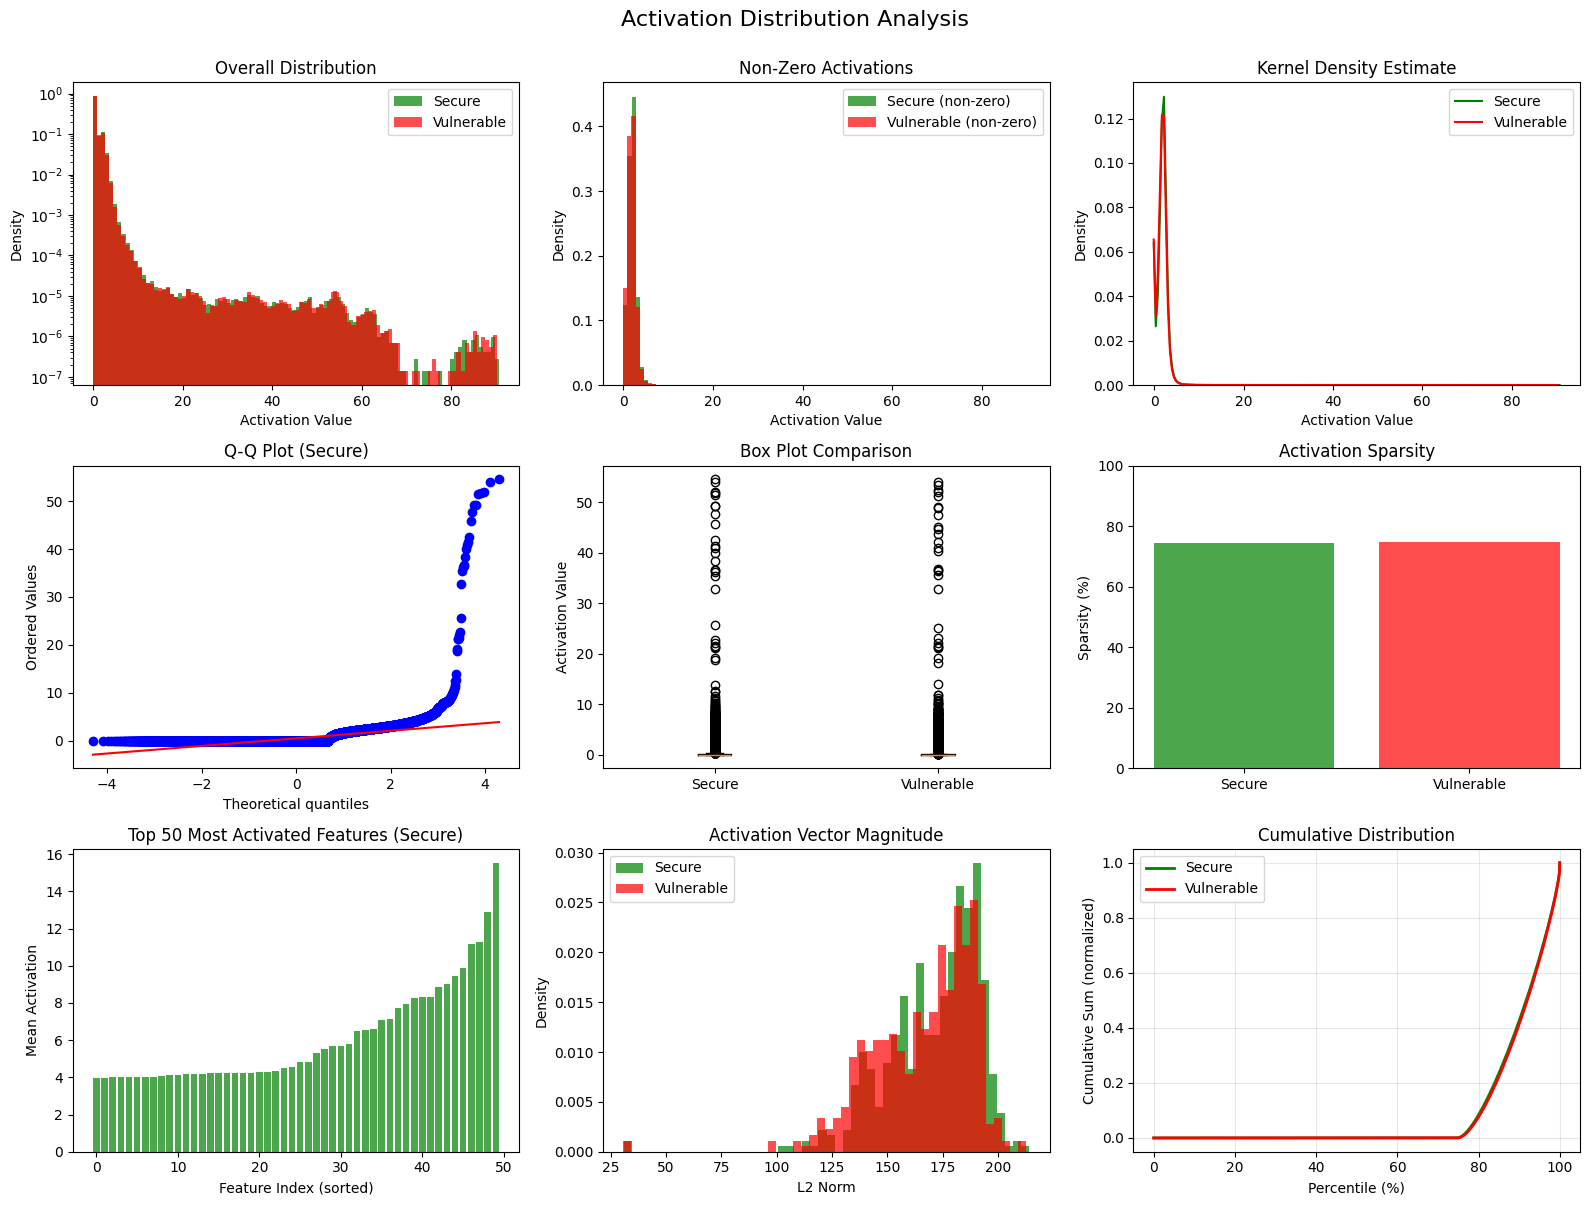

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import Dict, Any

def measure_activation_distribution(activations: torch.Tensor, name: str = "Activations") -> Dict[str, Any]:
    """
    Comprehensive measurement of activation distribution statistics.
    
    Args:
        activations: Tensor of shape (n_samples, n_features)
        name: Name for the distribution (e.g., "Secure", "Vulnerable")
    
    Returns:
        Dictionary containing distribution statistics
    """
    activations_np = activations.numpy()
    
    # Flatten for overall statistics
    flat_activations = activations_np.flatten()
    
    # Sparsity analysis
    threshold = 1e-6
    sparsity = (np.abs(flat_activations) < threshold).sum() / flat_activations.size
    
    # Basic statistics
    stats_dict = {
        "name": name,
        "n_samples": activations.shape[0],
        "n_features": activations.shape[1],
        # Overall statistics
        "mean": float(np.mean(flat_activations)),
        "std": float(np.std(flat_activations)),
        "median": float(np.median(flat_activations)),
        "min": float(np.min(flat_activations)),
        "max": float(np.max(flat_activations)),
        # Distribution shape
        "skewness": float(stats.skew(flat_activations)),
        "kurtosis": float(stats.kurtosis(flat_activations)),
        # Sparsity
        "sparsity": float(sparsity),
        "active_ratio": float(1 - sparsity),
        # Percentiles
        "p25": float(np.percentile(flat_activations, 25)),
        "p75": float(np.percentile(flat_activations, 75)),
        "p95": float(np.percentile(flat_activations, 95)),
        "p99": float(np.percentile(flat_activations, 99)),
        # Per-feature statistics
        "mean_per_feature": np.mean(activations_np, axis=0),
        "std_per_feature": np.std(activations_np, axis=0),
        "max_per_feature": np.max(activations_np, axis=0),
        # Top activated features
        "top_10_features": np.argsort(np.mean(activations_np, axis=0))[-10:][::-1],
        "top_10_values": np.sort(np.mean(activations_np, axis=0))[-10:][::-1],
    }
    
    return stats_dict


def plot_activation_distribution(secure_activations: torch.Tensor, 
                                 vulnerable_activations: torch.Tensor = None,
                                 figsize=(16, 12)):
    """
    Create comprehensive visualization of activation distributions.
    
    Args:
        secure_activations: Tensor of secure code activations
        vulnerable_activations: Optional tensor of vulnerable code activations for comparison
    """
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    fig.suptitle('Activation Distribution Analysis', fontsize=16, y=1.00)
    
    secure_flat = secure_activations.numpy().flatten()
    
    # 1. Overall histogram
    ax = axes[0, 0]
    ax.hist(secure_flat, bins=100, alpha=0.7, label='Secure', color='green', density=True)
    if vulnerable_activations is not None:
        vuln_flat = vulnerable_activations.numpy().flatten()
        ax.hist(vuln_flat, bins=100, alpha=0.7, label='Vulnerable', color='red', density=True)
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Density')
    ax.set_title('Overall Distribution')
    ax.legend()
    ax.set_yscale('log')
    
    # 2. Distribution without zeros (non-sparse activations)
    ax = axes[0, 1]
    secure_nonzero = secure_flat[np.abs(secure_flat) > 1e-6]
    ax.hist(secure_nonzero, bins=100, alpha=0.7, label='Secure (non-zero)', color='green', density=True)
    if vulnerable_activations is not None:
        vuln_nonzero = vuln_flat[np.abs(vuln_flat) > 1e-6]
        ax.hist(vuln_nonzero, bins=100, alpha=0.7, label='Vulnerable (non-zero)', color='red', density=True)
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Density')
    ax.set_title('Non-Zero Activations')
    ax.legend()
    
    # 3. KDE plot
    ax = axes[0, 2]
    sns.kdeplot(secure_flat, ax=ax, label='Secure', color='green', warn_singular=False)
    if vulnerable_activations is not None:
        sns.kdeplot(vuln_flat, ax=ax, label='Vulnerable', color='red', warn_singular=False)
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Density')
    ax.set_title('Kernel Density Estimate')
    ax.legend()
    
    # 4. Q-Q plot (normality test)
    ax = axes[1, 0]
    stats.probplot(secure_flat[::100], dist="norm", plot=ax)  # Subsample for speed
    ax.set_title('Q-Q Plot (Secure)')
    
    # 5. Box plot comparison
    ax = axes[1, 1]
    if vulnerable_activations is not None:
        data_to_plot = [secure_flat[::100], vuln_flat[::100]]  # Subsample
        ax.boxplot(data_to_plot, labels=['Secure', 'Vulnerable'])
    else:
        ax.boxplot([secure_flat[::100]], labels=['Secure'])
    ax.set_ylabel('Activation Value')
    ax.set_title('Box Plot Comparison')
    
    # 6. Sparsity comparison
    ax = axes[1, 2]
    secure_sparsity = (np.abs(secure_flat) < 1e-6).sum() / secure_flat.size * 100
    if vulnerable_activations is not None:
        vuln_sparsity = (np.abs(vuln_flat) < 1e-6).sum() / vuln_flat.size * 100
        ax.bar(['Secure', 'Vulnerable'], [secure_sparsity, vuln_sparsity], 
               color=['green', 'red'], alpha=0.7)
    else:
        ax.bar(['Secure'], [secure_sparsity], color=['green'], alpha=0.7)
    ax.set_ylabel('Sparsity (%)')
    ax.set_title('Activation Sparsity')
    ax.set_ylim([0, 100])
    
    # 7. Mean activation per feature (top features)
    ax = axes[2, 0]
    mean_per_feature = np.mean(secure_activations.numpy(), axis=0)
    top_n = 50
    top_indices = np.argsort(mean_per_feature)[-top_n:]
    ax.bar(range(top_n), mean_per_feature[top_indices], color='green', alpha=0.7)
    ax.set_xlabel('Feature Index (sorted)')
    ax.set_ylabel('Mean Activation')
    ax.set_title(f'Top {top_n} Most Activated Features (Secure)')
    
    # 8. Activation magnitude distribution
    ax = axes[2, 1]
    secure_magnitudes = np.linalg.norm(secure_activations.numpy(), axis=1)
    ax.hist(secure_magnitudes, bins=50, alpha=0.7, label='Secure', color='green', density=True)
    if vulnerable_activations is not None:
        vuln_magnitudes = np.linalg.norm(vulnerable_activations.numpy(), axis=1)
        ax.hist(vuln_magnitudes, bins=50, alpha=0.7, label='Vulnerable', color='red', density=True)
    ax.set_xlabel('L2 Norm')
    ax.set_ylabel('Density')
    ax.set_title('Activation Vector Magnitude')
    ax.legend()
    
    # 9. Cumulative distribution
    ax = axes[2, 2]
    secure_sorted = np.sort(np.abs(secure_flat))
    cumsum_secure = np.cumsum(secure_sorted)
    cumsum_secure = cumsum_secure / cumsum_secure[-1]
    ax.plot(np.linspace(0, 100, len(cumsum_secure)), cumsum_secure, 
            label='Secure', color='green', linewidth=2)
    if vulnerable_activations is not None:
        vuln_sorted = np.sort(np.abs(vuln_flat))
        cumsum_vuln = np.cumsum(vuln_sorted)
        cumsum_vuln = cumsum_vuln / cumsum_vuln[-1]
        ax.plot(np.linspace(0, 100, len(cumsum_vuln)), cumsum_vuln, 
                label='Vulnerable', color='red', linewidth=2)
    ax.set_xlabel('Percentile (%)')
    ax.set_ylabel('Cumulative Sum (normalized)')
    ax.set_title('Cumulative Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def print_distribution_stats(stats_dict: Dict[str, Any]):
    """Pretty print distribution statistics."""
    print(f"\n{'='*60}")
    print(f"  {stats_dict['name']} Activation Distribution Statistics")
    print(f"{'='*60}")
    print(f"Dataset Size:")
    print(f"  Samples: {stats_dict['n_samples']:,}")
    print(f"  Features: {stats_dict['n_features']:,}")
    print(f"\nBasic Statistics:")
    print(f"  Mean:   {stats_dict['mean']:>10.6f}")
    print(f"  Std:    {stats_dict['std']:>10.6f}")
    print(f"  Median: {stats_dict['median']:>10.6f}")
    print(f"  Min:    {stats_dict['min']:>10.6f}")
    print(f"  Max:    {stats_dict['max']:>10.6f}")
    print(f"\nDistribution Shape:")
    print(f"  Skewness: {stats_dict['skewness']:>8.4f}")
    print(f"  Kurtosis: {stats_dict['kurtosis']:>8.4f}")
    print(f"\nSparsity:")
    print(f"  Sparsity:     {stats_dict['sparsity']*100:>6.2f}%")
    print(f"  Active Ratio: {stats_dict['active_ratio']*100:>6.2f}%")
    print(f"\nPercentiles:")
    print(f"  25th: {stats_dict['p25']:>10.6f}")
    print(f"  75th: {stats_dict['p75']:>10.6f}")
    print(f"  95th: {stats_dict['p95']:>10.6f}")
    print(f"  99th: {stats_dict['p99']:>10.6f}")
    print(f"\nTop 10 Most Activated Features:")
    for i, (feat_idx, feat_val) in enumerate(zip(stats_dict['top_10_features'], 
                                                   stats_dict['top_10_values'])):
        print(f"  {i+1}. Feature {feat_idx:>5d}: {feat_val:>10.6f}")
    print(f"{'='*60}\n")


# Load secure activations and analyze
print("Loading secure activations...")
secure_activations = torch.load(f"../artifacts/activations/{RUN_ID}/safe_layer_0.pt")
vulnerable_activations = torch.load(f"../artifacts/activations/{RUN_ID}/vulnerable_layer_0.pt")

print(f"Secure shape: {secure_activations.shape}")
print(f"Vulnerable shape: {vulnerable_activations.shape}")

# Measure distributions
secure_stats = measure_activation_distribution(secure_activations, "Secure Code")
vulnerable_stats = measure_activation_distribution(vulnerable_activations, "Vulnerable Code")

# Print statistics
print_distribution_stats(secure_stats)
print_distribution_stats(vulnerable_stats)

# Visualize
plot_activation_distribution(secure_activations, vulnerable_activations)


  Distribution Comparison: Secure vs Vulnerable

Difference in Basic Statistics (Vulnerable - Secure):
  Mean Difference:    -0.027646
  Std Difference:     -0.027976
  Median Difference:   0.000000

Relative Differences (%):
  Mean:        -5.39%
  Std:         -2.25%
  Sparsity:     0.21%

Distribution Shape Comparison:
  Skewness Difference:   1.4441
  Kurtosis Difference:  87.0682

Sparsity Comparison:
  Secure Sparsity:      74.61%
  Vulnerable Sparsity:  74.77%
  Difference:            0.16%


  Statistical Tests (Secure vs Vulnerable)
Sample size: 100,000 activations

Kolmogorov-Smirnov Test:
  Statistic: 0.014630
  P-value:   1.002048e-09
  Result:    Distributions are DIFFERENT (α=0.05)

Mann-Whitney U Test:
  Statistic: 5029986459.500000
  P-value:   2.383986e-03
  Result:    Medians are DIFFERENT (α=0.05)

Wasserstein Distance (Earth Mover's Distance):
  Distance: 0.031973
  Interpretation: Small distributional difference


  Top 20 Most Differentiating Features
Feature    

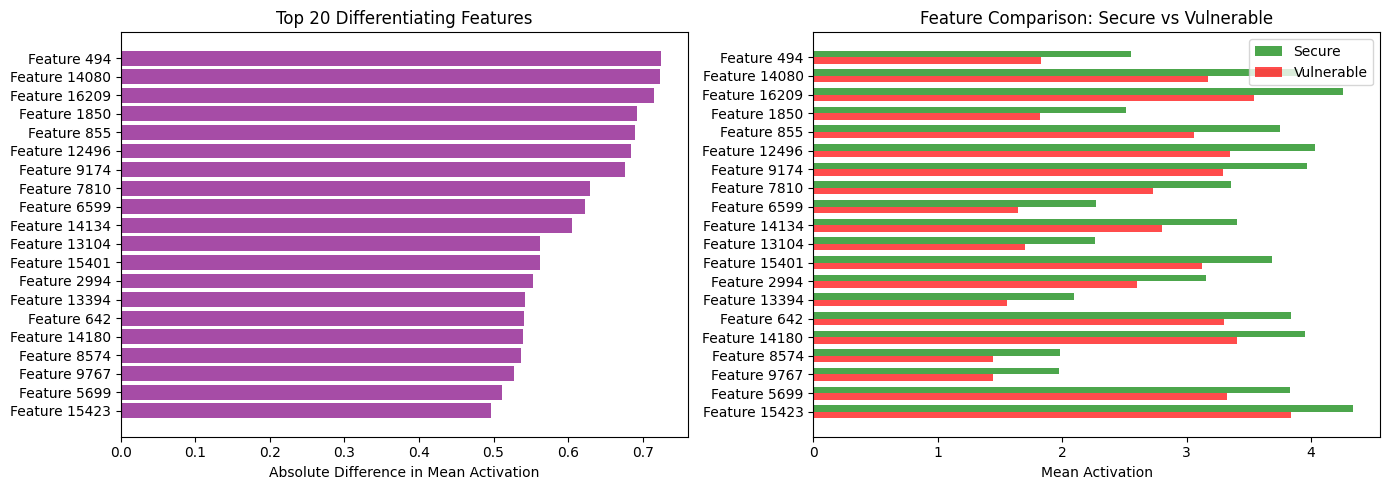

Results saved to: ../artifacts/activations/run_20260128_184854/distribution_analysis.json


In [27]:
from scipy.stats import ks_2samp, mannwhitneyu, wasserstein_distance
import json

def compare_distributions(secure_stats: Dict, vulnerable_stats: Dict) -> Dict[str, Any]:
    """
    Statistical comparison between secure and vulnerable code distributions.
    """
    print(f"\n{'='*60}")
    print(f"  Distribution Comparison: Secure vs Vulnerable")
    print(f"{'='*60}")
    
    # Difference in basic statistics
    print("\nDifference in Basic Statistics (Vulnerable - Secure):")
    print(f"  Mean Difference:   {vulnerable_stats['mean'] - secure_stats['mean']:>10.6f}")
    print(f"  Std Difference:    {vulnerable_stats['std'] - secure_stats['std']:>10.6f}")
    print(f"  Median Difference: {vulnerable_stats['median'] - secure_stats['median']:>10.6f}")
    
    # Relative differences
    print("\nRelative Differences (%):")
    rel_mean = ((vulnerable_stats['mean'] - secure_stats['mean']) / (abs(secure_stats['mean']) + 1e-10)) * 100
    rel_std = ((vulnerable_stats['std'] - secure_stats['std']) / (abs(secure_stats['std']) + 1e-10)) * 100
    rel_sparsity = ((vulnerable_stats['sparsity'] - secure_stats['sparsity']) / (secure_stats['sparsity'] + 1e-10)) * 100
    
    print(f"  Mean:     {rel_mean:>8.2f}%")
    print(f"  Std:      {rel_std:>8.2f}%")
    print(f"  Sparsity: {rel_sparsity:>8.2f}%")
    
    # Distribution shape comparison
    print("\nDistribution Shape Comparison:")
    print(f"  Skewness Difference: {vulnerable_stats['skewness'] - secure_stats['skewness']:>8.4f}")
    print(f"  Kurtosis Difference: {vulnerable_stats['kurtosis'] - secure_stats['kurtosis']:>8.4f}")
    
    # Sparsity comparison
    print("\nSparsity Comparison:")
    print(f"  Secure Sparsity:     {secure_stats['sparsity']*100:>6.2f}%")
    print(f"  Vulnerable Sparsity: {vulnerable_stats['sparsity']*100:>6.2f}%")
    print(f"  Difference:          {(vulnerable_stats['sparsity'] - secure_stats['sparsity'])*100:>6.2f}%")
    
    print(f"{'='*60}\n")
    
    return {
        "mean_diff": vulnerable_stats['mean'] - secure_stats['mean'],
        "std_diff": vulnerable_stats['std'] - secure_stats['std'],
        "median_diff": vulnerable_stats['median'] - secure_stats['median'],
        "sparsity_diff": vulnerable_stats['sparsity'] - secure_stats['sparsity'],
        "skewness_diff": vulnerable_stats['skewness'] - secure_stats['skewness'],
        "kurtosis_diff": vulnerable_stats['kurtosis'] - secure_stats['kurtosis'],
        "rel_mean_diff_pct": rel_mean,
        "rel_std_diff_pct": rel_std,
        "rel_sparsity_diff_pct": rel_sparsity,
    }


def statistical_tests(secure_activations: torch.Tensor, vulnerable_activations: torch.Tensor):
    """
    Perform statistical tests to compare distributions.
    """
    secure_flat = secure_activations.numpy().flatten()
    vuln_flat = vulnerable_activations.numpy().flatten()
    
    # Subsample for computational efficiency
    sample_size = min(100000, len(secure_flat), len(vuln_flat))
    secure_sample = np.random.choice(secure_flat, size=sample_size, replace=False)
    vuln_sample = np.random.choice(vuln_flat, size=sample_size, replace=False)
    
    print(f"\n{'='*60}")
    print(f"  Statistical Tests (Secure vs Vulnerable)")
    print(f"{'='*60}")
    print(f"Sample size: {sample_size:,} activations\n")
    
    # Kolmogorov-Smirnov test
    ks_stat, ks_pval = ks_2samp(secure_sample, vuln_sample)
    print("Kolmogorov-Smirnov Test:")
    print(f"  Statistic: {ks_stat:.6f}")
    print(f"  P-value:   {ks_pval:.6e}")
    print(f"  Result:    {'Distributions are DIFFERENT' if ks_pval < 0.05 else 'Distributions are SIMILAR'} (α=0.05)")
    
    # Mann-Whitney U test
    mw_stat, mw_pval = mannwhitneyu(secure_sample, vuln_sample, alternative='two-sided')
    print("\nMann-Whitney U Test:")
    print(f"  Statistic: {mw_stat:.6f}")
    print(f"  P-value:   {mw_pval:.6e}")
    print(f"  Result:    {'Medians are DIFFERENT' if mw_pval < 0.05 else 'Medians are SIMILAR'} (α=0.05)")
    
    # Wasserstein distance (Earth Mover's Distance)
    # Subsample more aggressively for Wasserstein
    ws_sample_size = min(10000, len(secure_flat), len(vuln_flat))
    secure_ws = np.random.choice(secure_flat, size=ws_sample_size, replace=False)
    vuln_ws = np.random.choice(vuln_flat, size=ws_sample_size, replace=False)
    ws_dist = wasserstein_distance(secure_ws, vuln_ws)
    print("\nWasserstein Distance (Earth Mover's Distance):")
    print(f"  Distance: {ws_dist:.6f}")
    print(f"  Interpretation: {'Large' if ws_dist > 0.1 else 'Small'} distributional difference")
    
    print(f"{'='*60}\n")
    
    return {
        "ks_statistic": ks_stat,
        "ks_pvalue": ks_pval,
        "mw_statistic": mw_stat,
        "mw_pvalue": mw_pval,
        "wasserstein_distance": ws_dist,
    }


def feature_wise_analysis(secure_activations: torch.Tensor, vulnerable_activations: torch.Tensor, top_n: int = 20):
    """
    Analyze which features differ most between secure and vulnerable code.
    """
    secure_mean = np.mean(secure_activations.numpy(), axis=0)
    vuln_mean = np.mean(vulnerable_activations.numpy(), axis=0)
    
    # Absolute difference
    diff = vuln_mean - secure_mean
    abs_diff = np.abs(diff)
    
    # Get top differentiating features
    top_indices = np.argsort(abs_diff)[-top_n:][::-1]
    
    print(f"\n{'='*60}")
    print(f"  Top {top_n} Most Differentiating Features")
    print(f"{'='*60}")
    print(f"{'Feature':<10} {'Secure':>12} {'Vulnerable':>12} {'Difference':>12} {'%Change':>10}")
    print(f"{'-'*60}")
    
    for idx in top_indices:
        pct_change = ((vuln_mean[idx] - secure_mean[idx]) / (abs(secure_mean[idx]) + 1e-10)) * 100
        print(f"{idx:<10} {secure_mean[idx]:>12.6f} {vuln_mean[idx]:>12.6f} {diff[idx]:>12.6f} {pct_change:>9.2f}%")
    
    print(f"{'='*60}\n")
    
    # Plot top differentiating features
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot of differences
    ax1.barh(range(top_n), abs_diff[top_indices], color='purple', alpha=0.7)
    ax1.set_yticks(range(top_n))
    ax1.set_yticklabels([f"Feature {i}" for i in top_indices])
    ax1.set_xlabel('Absolute Difference in Mean Activation')
    ax1.set_title(f'Top {top_n} Differentiating Features')
    ax1.invert_yaxis()
    
    # Comparison plot
    x = np.arange(top_n)
    width = 0.35
    ax2.barh(x - width/2, secure_mean[top_indices], width, label='Secure', color='green', alpha=0.7)
    ax2.barh(x + width/2, vuln_mean[top_indices], width, label='Vulnerable', color='red', alpha=0.7)
    ax2.set_yticks(x)
    ax2.set_yticklabels([f"Feature {i}" for i in top_indices])
    ax2.set_xlabel('Mean Activation')
    ax2.set_title('Feature Comparison: Secure vs Vulnerable')
    ax2.legend()
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    return {
        "top_features": top_indices.tolist(),
        "differences": diff[top_indices].tolist(),
        "secure_means": secure_mean[top_indices].tolist(),
        "vulnerable_means": vuln_mean[top_indices].tolist(),
    }


# Run comparison analyses
comparison_results = compare_distributions(secure_stats, vulnerable_stats)
test_results = statistical_tests(secure_activations, vulnerable_activations)
feature_results = feature_wise_analysis(secure_activations, vulnerable_activations, top_n=20)

# Save all results to JSON
results_summary = {
    "run_id": RUN_ID,
    "layer": 0,
    "secure_stats": {k: v for k, v in secure_stats.items() if not isinstance(v, np.ndarray)},
    "vulnerable_stats": {k: v for k, v in vulnerable_stats.items() if not isinstance(v, np.ndarray)},
    "comparison": comparison_results,
    "statistical_tests": test_results,
    "feature_analysis": feature_results,
}

output_file = f"../artifacts/activations/{RUN_ID}/distribution_analysis.json"
with open(output_file, "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"Results saved to: {output_file}")

## Step 1: Define Secure Activation Ranges (Invariants)

For each SAE feature, we compute robust statistics on secure code to establish "normal" activation patterns.
These are **invariants** (expected ranges), not thresholds.

### FIX: Handling Sparse Features

**Problem:** Using MAD on mostly-zero features is invalid. When `median = 0` and `MAD = 0`, the secure range becomes `[0, 0]`, so any nonzero activation is flagged as an outlier. This treats feature awakenings as violations, inflating outlier counts with false positives.

**Solution:** For sparse features (>50% zeros):
- **Zero/near-zero values**: NOT outliers (expected inactive state)
- **Nonzero values**: Checked against statistics computed from nonzero activations only

This prevents:
- False violations from dormant features suddenly activating
- Noise inflation in outlier counts
- Treating normal feature awakenings as anomalies

**Implementation:**
- Added `sparsity` field to track percentage of near-zero values
- Added `nonzero_*` fields for median, MAD, IQR computed on active values only
- Updated `is_outlier_mad()` and `is_outlier_iqr()` to use appropriate statistics based on feature sparsity

STEP 1: Computing Secure Activation Ranges (Invariants)
Computing secure activation ranges for 16384 features...


Processing features: 100%|██████████| 16384/16384 [00:04<00:00, 3449.08it/s]



  Secure Activation Range Summary
Total features: 16384
MAD multiplier (k): 2.0
IQR multiplier (k): 1.5

Robustness Statistics:
  Features with MAD = 0 (constant): 12169 (74.27%)
  Features with IQR = 0 (constant): 12060 (73.61%)
  Sparse features (>50% zeros): 12169 (74.27%)

Sparsity Distribution:
  Mean sparsity:   74.61%
  Median sparsity: 100.00%
  Min sparsity:    0.00%
  Max sparsity:    100.00%

MAD Distribution:
  Mean MAD:   0.107923
  Median MAD: 0.000000
  Min MAD:    0.000000
  Max MAD:    1.943028

IQR Distribution:
  Mean IQR:   0.229443
  Median IQR: 0.000000
  Min IQR:    0.000000
  Max IQR:    25.179092

Median Distribution:
  Mean Median:   0.498760
  Median Median: 0.000000
  Min Median:    0.000000
  Max Median:    5.227837

Top 10 Features by MAD (highest variability in secure code):
  1. Feature 14791: median=  2.6074, MAD=  1.9430, range=[ -1.2787,   6.4935]
  2. Feature   494: median=  1.8864, MAD=  1.8864, range=[ -1.8864,   5.6593]
  3. Feature 14348: median

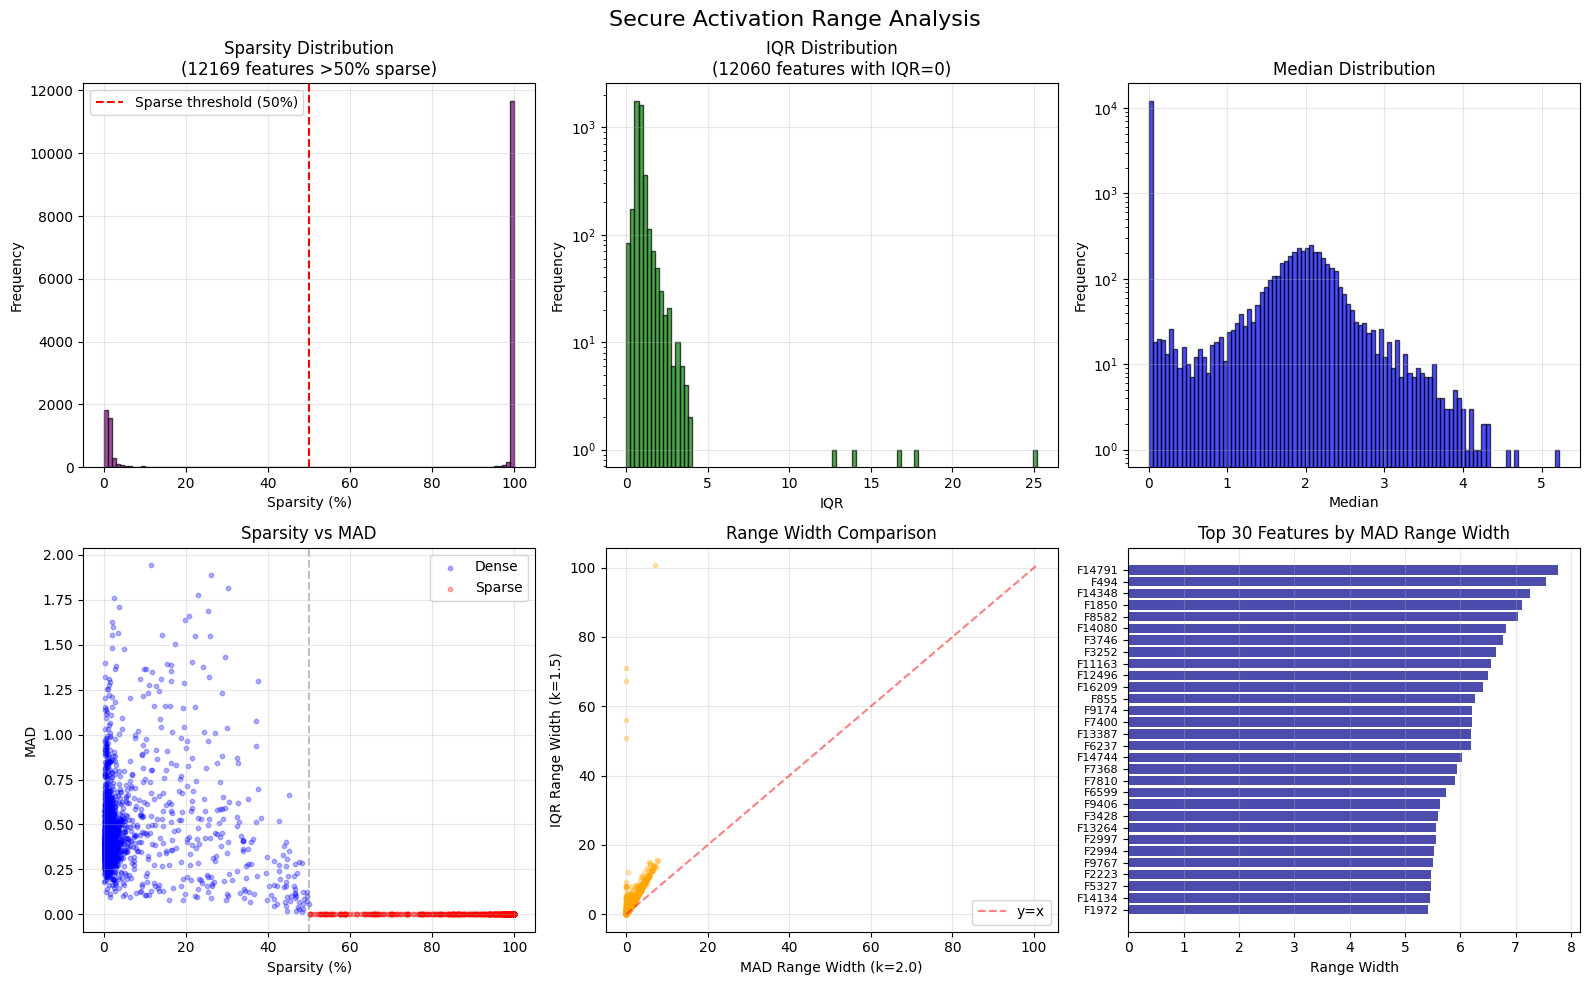

Secure ranges saved to: ../artifacts/activations/run_20260128_184854/secure_ranges_layer_0.pkl


In [36]:
from dataclasses import dataclass
from typing import Optional
import pickle
from tqdm import tqdm
import numpy as np
import torch
import matplotlib.pyplot as plt

secure_activations = all_safe_features["layer_0"]
vulnerable_activations = all_vulnerable_features["layer_0"]


@dataclass
class SecureActivationRange:
    """Invariants for secure code activation patterns."""
    feature_idx: int
    median: float
    mad: float  # Median Absolute Deviation
    iqr: float  # Interquartile Range
    q1: float   # 25th percentile
    q3: float   # 75th percentile
    mean: float  # For reference
    std: float   # For reference
    
    # NEW: Statistics for handling sparse features
    sparsity: float = 0.0  # Fraction of near-zero values
    nonzero_median: Optional[float] = None
    nonzero_mad: Optional[float] = None
    nonzero_q1: Optional[float] = None
    nonzero_q3: Optional[float] = None
    nonzero_iqr: Optional[float] = None
    
    def is_sparse(self, threshold: float = 0.5) -> bool:
        """
        Feature is sparse if >50% of activations are near-zero.
        This indicates a feature that is mostly inactive.
        """
        return self.sparsity > threshold
    
    def get_range_mad(self, k: float = 2.0) -> tuple[float, float]:
        """Get secure range using MAD: [median - k*MAD, median + k*MAD]"""
        return (self.median - k * self.mad, self.median + k * self.mad)
    
    def get_range_iqr(self, k: float = 1.5) -> tuple[float, float]:
        """Get secure range using IQR: [Q1 - k*IQR, Q3 + k*IQR]"""
        return (self.q1 - k * self.iqr, self.q3 + k * self.iqr)
    
    def is_outlier_mad(self, value: float, k: float = 2.0) -> bool:
        """
        Check if a value is outside the MAD-based secure range.
        
        For sparse features (>50% zeros):
        - Zero/near-zero values are NOT outliers (expected inactive state)
        - Nonzero values are checked against nonzero-only statistics
        
        For dense features:
        - Standard MAD-based outlier detection
        """
        # For sparse features, use separate logic
        if self.is_sparse() and self.nonzero_mad is not None:
            # If value is near-zero, it's NOT an outlier (normal inactive state)
            if abs(value) < 1e-6:
                return False
            # If value is nonzero, check against nonzero range
            lower = self.nonzero_median - k * self.nonzero_mad
            upper = self.nonzero_median + k * self.nonzero_mad
            return value < lower or value > upper
        
        # For dense features: use standard MAD range
        if self.mad == 0:
            return False  # Constant feature → no outliers
        lower, upper = self.get_range_mad(k)
        return value < lower or value > upper
    
    def is_outlier_iqr(self, value: float, k: float = 1.5) -> bool:
        """
        Check if a value is outside the IQR-based secure range.
        
        For sparse features:
        - Zero/near-zero values are NOT outliers
        - Nonzero values are checked against nonzero-only statistics
        """
        # For sparse features, use separate logic
        if self.is_sparse() and self.nonzero_iqr is not None:
            # If value is near-zero, it's NOT an outlier
            if abs(value) < 1e-6:
                return False
            # If value is nonzero, check against nonzero range
            lower = self.nonzero_q1 - k * self.nonzero_iqr
            upper = self.nonzero_q3 + k * self.nonzero_iqr
            return value < lower or value > upper
        
        # For dense features: use standard IQR range
        if self.iqr == 0:
            return False  # Constant feature → no outliers
        lower, upper = self.get_range_iqr(k)
        return value < lower or value > upper
    
    def deviation_score_mad(self, value: float) -> float:
        """
        Compute how many MADs a value is from the median.
        
        For sparse features:
        - Returns 0 for near-zero values (expected state)
        - Computes deviation from nonzero median for active values
        """
        # For sparse features
        if self.is_sparse() and self.nonzero_mad is not None:
            # Near-zero values have zero deviation (expected)
            if abs(value) < 1e-6:
                return 0.0
            # Nonzero values: deviation from nonzero distribution
            if self.nonzero_mad == 0:
                return 0.0
            return abs(value - self.nonzero_median) / self.nonzero_mad
        
        # For dense features
        if self.mad == 0:
            return 0.0
        return abs(value - self.median) / self.mad
    
    def deviation_score_iqr(self, value: float) -> float:
        """
        Compute deviation in terms of IQR.
        
        For sparse features:
        - Returns 0 for near-zero values
        - Uses nonzero IQR for active values
        """
        # For sparse features
        if self.is_sparse() and self.nonzero_iqr is not None:
            # Near-zero values have zero deviation
            if abs(value) < 1e-6:
                return 0.0
            # Nonzero values: deviation from nonzero quartiles
            if self.nonzero_iqr == 0:
                return 0.0
            if value < self.nonzero_q1:
                return (self.nonzero_q1 - value) / self.nonzero_iqr
            elif value > self.nonzero_q3:
                return (value - self.nonzero_q3) / self.nonzero_iqr
            else:
                return 0.0  # Within IQR
        
        # For dense features
        if self.iqr == 0:
            return 0.0
        # Distance from the nearest quartile boundary
        if value < self.q1:
            return (self.q1 - value) / self.iqr
        elif value > self.q3:
            return (value - self.q3) / self.iqr
        else:
            return 0.0  # Within IQR


def compute_mad(values: np.ndarray) -> float:
    """
    Compute Median Absolute Deviation (MAD).
    MAD = median(|x_i - median(x)|)
    """
    median = np.median(values)
    return np.median(np.abs(values - median))


def compute_secure_ranges(secure_activations: torch.Tensor) -> list[SecureActivationRange]:
    """
    Compute secure activation ranges for all features.
    
    Args:
        secure_activations: Tensor of shape (n_samples, n_features)
    
    Returns:
        List of SecureActivationRange objects, one per feature
    """
    secure_np = secure_activations.numpy()
    n_features = secure_np.shape[1]
    
    ranges = []
    
    print(f"Computing secure activation ranges for {n_features} features...")
    
    ZERO_THRESHOLD = 1e-6
    
    for i in tqdm(range(n_features), desc="Processing features"):
        feature_values = secure_np[:, i]
        
        # Compute sparsity
        sparsity = (np.abs(feature_values) < ZERO_THRESHOLD).sum() / len(feature_values)
        
        # Robust statistics (all values)
        median = np.median(feature_values)
        mad = compute_mad(feature_values)
        
        # IQR statistics (all values)
        q1 = np.percentile(feature_values, 25)
        q3 = np.percentile(feature_values, 75)
        iqr = q3 - q1
        
        # Classical statistics (for reference)
        mean = np.mean(feature_values)
        std = np.std(feature_values)
        
        # NEW: Compute statistics for nonzero values only (for sparse features)
        nonzero_mask = np.abs(feature_values) >= ZERO_THRESHOLD
        nonzero_values = feature_values[nonzero_mask]
        
        nonzero_median = None
        nonzero_mad = None
        nonzero_q1 = None
        nonzero_q3 = None
        nonzero_iqr = None
        
        if len(nonzero_values) > 0:
            nonzero_median = np.median(nonzero_values)
            nonzero_mad = compute_mad(nonzero_values)
            nonzero_q1 = np.percentile(nonzero_values, 25)
            nonzero_q3 = np.percentile(nonzero_values, 75)
            nonzero_iqr = nonzero_q3 - nonzero_q1
        
        ranges.append(SecureActivationRange(
            feature_idx=i,
            median=median,
            mad=mad,
            iqr=iqr,
            q1=q1,
            q3=q3,
            mean=mean,
            std=std,
            sparsity=sparsity,
            nonzero_median=nonzero_median,
            nonzero_mad=nonzero_mad,
            nonzero_q1=nonzero_q1,
            nonzero_q3=nonzero_q3,
            nonzero_iqr=nonzero_iqr,
        ))
    
    return ranges


def summarize_secure_ranges(ranges: list[SecureActivationRange], k_mad: float = 2.0, k_iqr: float = 1.5):
    """Print summary statistics about the secure ranges."""
    print(f"\n{'='*70}")
    print(f"  Secure Activation Range Summary")
    print(f"{'='*70}")
    print(f"Total features: {len(ranges)}")
    print(f"MAD multiplier (k): {k_mad}")
    print(f"IQR multiplier (k): {k_iqr}")
    
    # Collect statistics
    mads = [r.mad for r in ranges]
    iqrs = [r.iqr for r in ranges]
    medians = [r.median for r in ranges]
    sparsities = [r.sparsity for r in ranges]
    
    # Features with zero variance (constant)
    zero_mad_count = sum(1 for mad in mads if mad == 0)
    zero_iqr_count = sum(1 for iqr in iqrs if iqr == 0)
    
    # Sparse features
    sparse_count = sum(1 for r in ranges if r.is_sparse())
    
    print(f"\nRobustness Statistics:")
    print(f"  Features with MAD = 0 (constant): {zero_mad_count} ({zero_mad_count/len(ranges)*100:.2f}%)")
    print(f"  Features with IQR = 0 (constant): {zero_iqr_count} ({zero_iqr_count/len(ranges)*100:.2f}%)")
    print(f"  Sparse features (>50% zeros): {sparse_count} ({sparse_count/len(ranges)*100:.2f}%)")
    
    print(f"\nSparsity Distribution:")
    print(f"  Mean sparsity:   {np.mean(sparsities)*100:.2f}%")
    print(f"  Median sparsity: {np.median(sparsities)*100:.2f}%")
    print(f"  Min sparsity:    {np.min(sparsities)*100:.2f}%")
    print(f"  Max sparsity:    {np.max(sparsities)*100:.2f}%")
    
    print(f"\nMAD Distribution:")
    print(f"  Mean MAD:   {np.mean(mads):.6f}")
    print(f"  Median MAD: {np.median(mads):.6f}")
    print(f"  Min MAD:    {np.min(mads):.6f}")
    print(f"  Max MAD:    {np.max(mads):.6f}")
    
    print(f"\nIQR Distribution:")
    print(f"  Mean IQR:   {np.mean(iqrs):.6f}")
    print(f"  Median IQR: {np.median(iqrs):.6f}")
    print(f"  Min IQR:    {np.min(iqrs):.6f}")
    print(f"  Max IQR:    {np.max(iqrs):.6f}")
    
    print(f"\nMedian Distribution:")
    print(f"  Mean Median:   {np.mean(medians):.6f}")
    print(f"  Median Median: {np.median(medians):.6f}")
    print(f"  Min Median:    {np.min(medians):.6f}")
    print(f"  Max Median:    {np.max(medians):.6f}")
    
    # Top features by spread
    print(f"\nTop 10 Features by MAD (highest variability in secure code):")
    sorted_by_mad = sorted(ranges, key=lambda r: r.mad, reverse=True)[:10]
    for i, r in enumerate(sorted_by_mad):
        lower, upper = r.get_range_mad(k_mad)
        sparse_indicator = " [SPARSE]" if r.is_sparse() else ""
        print(f"  {i+1}. Feature {r.feature_idx:>5d}: median={r.median:>8.4f}, MAD={r.mad:>8.4f}, range=[{lower:>8.4f}, {upper:>8.4f}]{sparse_indicator}")
    
    print(f"\nTop 10 Features by Median (highest baseline activation):")
    sorted_by_median = sorted(ranges, key=lambda r: r.median, reverse=True)[:10]
    for i, r in enumerate(sorted_by_median):
        lower, upper = r.get_range_mad(k_mad)
        sparse_indicator = " [SPARSE]" if r.is_sparse() else ""
        print(f"  {i+1}. Feature {r.feature_idx:>5d}: median={r.median:>8.4f}, MAD={r.mad:>8.4f}, range=[{lower:>8.4f}, {upper:>8.4f}]{sparse_indicator}")
    
    print(f"{'='*70}\n")


def visualize_secure_ranges(ranges: list[SecureActivationRange], k_mad: float = 2.0, k_iqr: float = 1.5):
    """Visualize the secure activation ranges."""
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Secure Activation Range Analysis', fontsize=16)
    
    # Extract statistics
    mads = np.array([r.mad for r in ranges])
    iqrs = np.array([r.iqr for r in ranges])
    medians = np.array([r.median for r in ranges])
    means = np.array([r.mean for r in ranges])
    stds = np.array([r.std for r in ranges])
    sparsities = np.array([r.sparsity for r in ranges])
    
    # 1. Sparsity Distribution
    ax = axes[0, 0]
    ax.hist(sparsities * 100, bins=100, alpha=0.7, color='purple', edgecolor='black')
    ax.set_xlabel('Sparsity (%)')
    ax.set_ylabel('Frequency')
    ax.axvline(50, color='red', linestyle='--', label='Sparse threshold (50%)')
    ax.set_title(f'Sparsity Distribution\n({sum(r.is_sparse() for r in ranges)} features >50% sparse)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. IQR Distribution
    ax = axes[0, 1]
    ax.hist(iqrs[iqrs > 0], bins=100, alpha=0.7, color='green', edgecolor='black')
    ax.set_xlabel('IQR')
    ax.set_ylabel('Frequency')
    ax.set_title(f'IQR Distribution\n({sum(iqrs==0)} features with IQR=0)')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # 3. Median Distribution
    ax = axes[0, 2]
    ax.hist(medians, bins=100, alpha=0.7, color='blue', edgecolor='black')
    ax.set_xlabel('Median')
    ax.set_ylabel('Frequency')
    ax.set_title('Median Distribution')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # 4. Sparsity vs MAD (scatter)
    ax = axes[1, 0]
    sparse_mask = np.array([r.is_sparse() for r in ranges])
    ax.scatter(sparsities[~sparse_mask] * 100, mads[~sparse_mask], 
              alpha=0.3, s=10, color='blue', label='Dense')
    ax.scatter(sparsities[sparse_mask] * 100, mads[sparse_mask], 
              alpha=0.3, s=10, color='red', label='Sparse')
    ax.set_xlabel('Sparsity (%)')
    ax.set_ylabel('MAD')
    ax.set_title('Sparsity vs MAD')
    ax.axvline(50, color='gray', linestyle='--', alpha=0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. Range widths comparison
    ax = axes[1, 1]
    mad_widths = np.array([r.get_range_mad(k_mad)[1] - r.get_range_mad(k_mad)[0] for r in ranges])
    iqr_widths = np.array([r.get_range_iqr(k_iqr)[1] - r.get_range_iqr(k_iqr)[0] for r in ranges])
    
    ax.scatter(mad_widths, iqr_widths, alpha=0.3, s=10, color='orange')
    ax.set_xlabel(f'MAD Range Width (k={k_mad})')
    ax.set_ylabel(f'IQR Range Width (k={k_iqr})')
    ax.set_title('Range Width Comparison')
    ax.plot([0, max(mad_widths.max(), iqr_widths.max())], 
            [0, max(mad_widths.max(), iqr_widths.max())], 
            'r--', alpha=0.5, label='y=x')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Top features by range width
    ax = axes[1, 2]
    top_n = 30
    sorted_by_mad_width = sorted(enumerate(mad_widths), key=lambda x: x[1], reverse=True)[:top_n]
    indices, widths = zip(*sorted_by_mad_width)
    
    ax.barh(range(top_n), widths, alpha=0.7, color='darkblue')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([f"F{ranges[i].feature_idx}" for i in indices], fontsize=8)
    ax.set_xlabel('Range Width')
    ax.set_title(f'Top {top_n} Features by MAD Range Width')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()


# Compute secure activation ranges
print("="*70)
print("STEP 1: Computing Secure Activation Ranges (Invariants)")
print("="*70)

secure_ranges = compute_secure_ranges(secure_activations)

# Summarize
summarize_secure_ranges(secure_ranges, k_mad=2.0, k_iqr=1.5)

# Visualize
visualize_secure_ranges(secure_ranges, k_mad=2.0, k_iqr=1.5)

# Save ranges for later use
output_path = f"../artifacts/activations/{RUN_ID}/secure_ranges_layer_0.pkl"
with open(output_path, 'wb') as f:
    pickle.dump(secure_ranges, f)
print(f"Secure ranges saved to: {output_path}")


  Population Comparison: Secure vs Vulnerable Range Violations
Using MAD with k=2.0, IQR with k=1.5



Analyzing vulnerable samples: 100%|██████████| 491/491 [00:37<00:00, 13.16it/s]
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_6340/1758585730.py:144: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,


MAD-based Outlier Rates:
  Secure:       5.29% ±  4.42%
  Vulnerable:   6.05% ±  5.08%
  Difference:   0.75%

IQR-based Outlier Rates:
  Secure:       0.84% ±  1.81%
  Vulnerable:   0.98% ±  2.09%
  Difference:   0.14%

Mean MAD Deviation Scores:
  Secure:     0.3583 ± 0.1494
  Vulnerable: 0.3782 ± 0.1623
  Difference: 0.0199



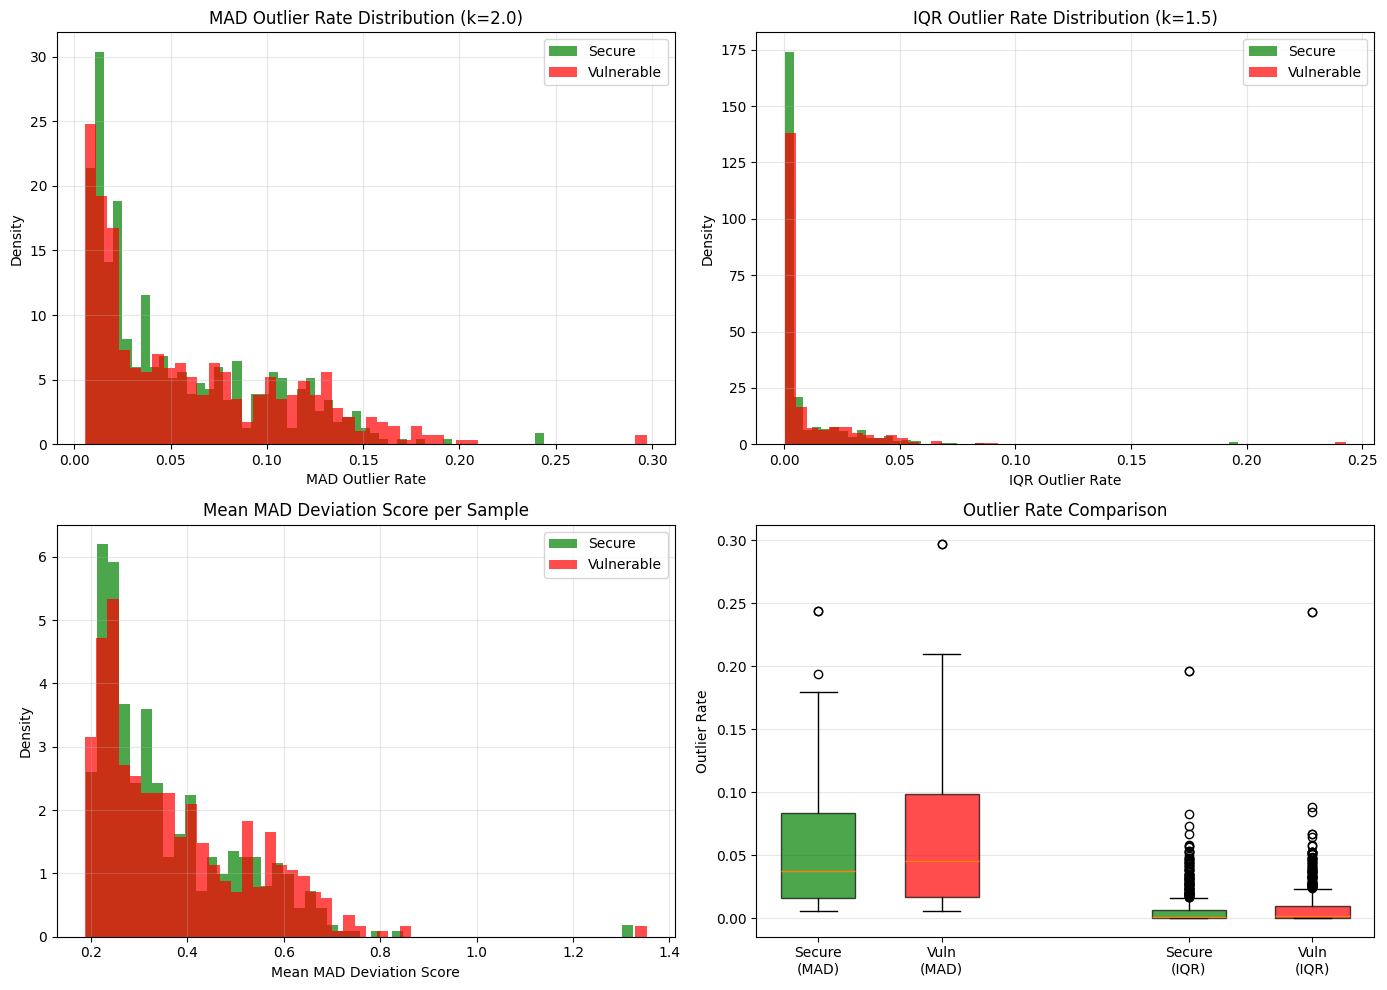


  Example Vulnerable Samples with Highest Deviation

Sample 251 (rank 1):
  MAD outliers: 4870 (29.72%)
  IQR outliers: 3982 (24.30%)
  Mean MAD score: 1.3529
  Max MAD score: 317.4663
  Top 5 violating features:
    Feature 11559: score=317.47, actual=  0.6999, expected=  0.0000
    Feature 11619: score=218.47, actual=  1.1289, expected=  0.0000
    Feature  5725: score= 97.01, actual=  0.0824, expected=  0.0000
    Feature 13584: score= 77.81, actual=  0.5980, expected=  0.0000
    Feature  2822: score= 37.10, actual=  2.1178, expected=  0.0000

Sample 252 (rank 2):
  MAD outliers: 4870 (29.72%)
  IQR outliers: 3982 (24.30%)
  Mean MAD score: 1.3529
  Max MAD score: 317.4663
  Top 5 violating features:
    Feature 11559: score=317.47, actual=  0.6999, expected=  0.0000
    Feature 11619: score=218.47, actual=  1.1289, expected=  0.0000
    Feature  5725: score= 97.01, actual=  0.0824, expected=  0.0000
    Feature 13584: score= 77.81, actual=  0.5980, expected=  0.0000
    Feature  

In [37]:
def analyze_sample_deviations(sample_activations: np.ndarray, 
                              ranges: list[SecureActivationRange], 
                              k_mad: float = 2.0,
                              k_iqr: float = 1.5) -> dict:
    """
    Analyze how a single sample deviates from secure ranges.
    
    Args:
        sample_activations: 1D array of activations for a single sample
        ranges: List of SecureActivationRange objects
        k_mad: MAD multiplier
        k_iqr: IQR multiplier
    
    Returns:
        Dictionary with deviation statistics
    """
    n_features = len(sample_activations)
    
    # Count outliers
    mad_outliers = []
    iqr_outliers = []
    
    # Deviation scores
    mad_scores = []
    iqr_scores = []
    
    for i, (activation, range_obj) in enumerate(zip(sample_activations, ranges)):
        # Check for outliers
        if range_obj.is_outlier_mad(activation, k_mad):
            mad_outliers.append(i)
        if range_obj.is_outlier_iqr(activation, k_iqr):
            iqr_outliers.append(i)
        
        # Compute deviation scores
        mad_scores.append(range_obj.deviation_score_mad(activation))
        iqr_scores.append(range_obj.deviation_score_iqr(activation))
    
    return {
        "n_features": n_features,
        "mad_outliers": mad_outliers,
        "iqr_outliers": iqr_outliers,
        "n_mad_outliers": len(mad_outliers),
        "n_iqr_outliers": len(iqr_outliers),
        "mad_outlier_rate": len(mad_outliers) / n_features,
        "iqr_outlier_rate": len(iqr_outliers) / n_features,
        "mad_scores": np.array(mad_scores),
        "iqr_scores": np.array(iqr_scores),
        "mean_mad_score": np.mean(mad_scores),
        "median_mad_score": np.median(mad_scores),
        "max_mad_score": np.max(mad_scores),
        "mean_iqr_score": np.mean(iqr_scores),
        "median_iqr_score": np.median(iqr_scores),
        "max_iqr_score": np.max(iqr_scores),
    }


def compare_populations(secure_activations: torch.Tensor, 
                       vulnerable_activations: torch.Tensor,
                       ranges: list[SecureActivationRange],
                       k_mad: float = 2.0,
                       k_iqr: float = 1.5):
    """
    Compare secure vs vulnerable populations in terms of range violations.
    """
    print(f"\n{'='*70}")
    print(f"  Population Comparison: Secure vs Vulnerable Range Violations")
    print(f"{'='*70}")
    print(f"Using MAD with k={k_mad}, IQR with k={k_iqr}\n")
    
    secure_np = secure_activations.numpy()
    vuln_np = vulnerable_activations.numpy()
    
    # Analyze all samples
    secure_results = [analyze_sample_deviations(sample, ranges, k_mad, k_iqr) 
                     for sample in tqdm(secure_np, desc="Analyzing secure samples")]
    vuln_results = [analyze_sample_deviations(sample, ranges, k_mad, k_iqr) 
                   for sample in tqdm(vuln_np, desc="Analyzing vulnerable samples")]
    
    # Aggregate statistics
    secure_mad_rates = [r["mad_outlier_rate"] for r in secure_results]
    vuln_mad_rates = [r["mad_outlier_rate"] for r in vuln_results]
    
    secure_iqr_rates = [r["iqr_outlier_rate"] for r in secure_results]
    vuln_iqr_rates = [r["iqr_outlier_rate"] for r in vuln_results]
    
    secure_mean_mad_scores = [r["mean_mad_score"] for r in secure_results]
    vuln_mean_mad_scores = [r["mean_mad_score"] for r in vuln_results]
    
    print("MAD-based Outlier Rates:")
    print(f"  Secure:     {np.mean(secure_mad_rates)*100:>6.2f}% ± {np.std(secure_mad_rates)*100:>5.2f}%")
    print(f"  Vulnerable: {np.mean(vuln_mad_rates)*100:>6.2f}% ± {np.std(vuln_mad_rates)*100:>5.2f}%")
    print(f"  Difference: {(np.mean(vuln_mad_rates) - np.mean(secure_mad_rates))*100:>6.2f}%")
    
    print(f"\nIQR-based Outlier Rates:")
    print(f"  Secure:     {np.mean(secure_iqr_rates)*100:>6.2f}% ± {np.std(secure_iqr_rates)*100:>5.2f}%")
    print(f"  Vulnerable: {np.mean(vuln_iqr_rates)*100:>6.2f}% ± {np.std(vuln_iqr_rates)*100:>5.2f}%")
    print(f"  Difference: {(np.mean(vuln_iqr_rates) - np.mean(secure_iqr_rates))*100:>6.2f}%")
    
    print(f"\nMean MAD Deviation Scores:")
    print(f"  Secure:     {np.mean(secure_mean_mad_scores):>6.4f} ± {np.std(secure_mean_mad_scores):>5.4f}")
    print(f"  Vulnerable: {np.mean(vuln_mean_mad_scores):>6.4f} ± {np.std(vuln_mean_mad_scores):>5.4f}")
    print(f"  Difference: {np.mean(vuln_mean_mad_scores) - np.mean(secure_mean_mad_scores):>6.4f}")
    
    print(f"{'='*70}\n")
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # MAD outlier rates
    ax = axes[0, 0]
    ax.hist(secure_mad_rates, bins=50, alpha=0.7, label='Secure', color='green', density=True)
    ax.hist(vuln_mad_rates, bins=50, alpha=0.7, label='Vulnerable', color='red', density=True)
    ax.set_xlabel('MAD Outlier Rate')
    ax.set_ylabel('Density')
    ax.set_title(f'MAD Outlier Rate Distribution (k={k_mad})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # IQR outlier rates
    ax = axes[0, 1]
    ax.hist(secure_iqr_rates, bins=50, alpha=0.7, label='Secure', color='green', density=True)
    ax.hist(vuln_iqr_rates, bins=50, alpha=0.7, label='Vulnerable', color='red', density=True)
    ax.set_xlabel('IQR Outlier Rate')
    ax.set_ylabel('Density')
    ax.set_title(f'IQR Outlier Rate Distribution (k={k_iqr})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Mean MAD scores
    ax = axes[1, 0]
    ax.hist(secure_mean_mad_scores, bins=50, alpha=0.7, label='Secure', color='green', density=True)
    ax.hist(vuln_mean_mad_scores, bins=50, alpha=0.7, label='Vulnerable', color='red', density=True)
    ax.set_xlabel('Mean MAD Deviation Score')
    ax.set_ylabel('Density')
    ax.set_title('Mean MAD Deviation Score per Sample')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Box plots for comparison
    ax = axes[1, 1]
    data = [secure_mad_rates, vuln_mad_rates, secure_iqr_rates, vuln_iqr_rates]
    positions = [1, 2, 4, 5]
    colors = ['green', 'red', 'green', 'red']
    bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                    labels=['Secure\n(MAD)', 'Vuln\n(MAD)', 'Secure\n(IQR)', 'Vuln\n(IQR)'])
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Outlier Rate')
    ax.set_title('Outlier Rate Comparison')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return {
        "secure_results": secure_results,
        "vuln_results": vuln_results,
        "summary": {
            "secure_mad_mean": np.mean(secure_mad_rates),
            "vuln_mad_mean": np.mean(vuln_mad_rates),
            "secure_iqr_mean": np.mean(secure_iqr_rates),
            "vuln_iqr_mean": np.mean(vuln_iqr_rates),
            "mad_diff": np.mean(vuln_mad_rates) - np.mean(secure_mad_rates),
            "iqr_diff": np.mean(vuln_iqr_rates) - np.mean(secure_iqr_rates),
        }
    }


# Run comparison analysis
comparison = compare_populations(secure_activations, vulnerable_activations, 
                                secure_ranges, k_mad=2.0, k_iqr=1.5)

# Show a few examples
print("\n" + "="*70)
print("  Example Vulnerable Samples with Highest Deviation")
print("="*70)

vuln_results = comparison["vuln_results"]
sorted_by_mad = sorted(enumerate(vuln_results), key=lambda x: x[1]["mean_mad_score"], reverse=True)

for rank, (idx, result) in enumerate(sorted_by_mad[:5]):
    print(f"\nSample {idx} (rank {rank+1}):")
    print(f"  MAD outliers: {result['n_mad_outliers']} ({result['mad_outlier_rate']*100:.2f}%)")
    print(f"  IQR outliers: {result['n_iqr_outliers']} ({result['iqr_outlier_rate']*100:.2f}%)")
    print(f"  Mean MAD score: {result['mean_mad_score']:.4f}")
    print(f"  Max MAD score: {result['max_mad_score']:.4f}")
    
    # Show top violating features
    mad_scores = result["mad_scores"]
    top_violations = np.argsort(mad_scores)[-5:][::-1]
    print(f"  Top 5 violating features:")
    for feat_idx in top_violations:
        score = mad_scores[feat_idx]
        actual = vulnerable_activations[idx, feat_idx].item()
        expected = secure_ranges[feat_idx].median
        print(f"    Feature {feat_idx:>5d}: score={score:>6.2f}, actual={actual:>8.4f}, expected={expected:>8.4f}")

print("="*70)